In [3]:
import pandas as pd
import numpy as np
import re
import string

from collections import Counter, defaultdict

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize

from spellchecker import SpellChecker

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
!pip install pyspellchecker

In [2]:
import sys
!{sys.executable} -m pip install pyspellchecker

  Using cached pyspellchecker-0.9.0-py3-none-any.whl.metadata (9.3 kB)
Using cached pyspellchecker-0.9.0-py3-none-any.whl (7.2 MB)



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
files = gutenberg.fileids()

print("Number of books:", len(files))
print("\nAvailable books:")
for file in files:
    print(file)

Number of books: 18

Available books:
austen-emma.txt
austen-persuasion.txt
austen-sense.txt
bible-kjv.txt
blake-poems.txt
bryant-stories.txt
burgess-busterbrown.txt
carroll-alice.txt
chesterton-ball.txt
chesterton-brown.txt
chesterton-thursday.txt
edgeworth-parents.txt
melville-moby_dick.txt
milton-paradise.txt
shakespeare-caesar.txt
shakespeare-hamlet.txt
shakespeare-macbeth.txt
whitman-leaves.txt


In [6]:
text = ""

for file in files:
    text += gutenberg.raw(file)

print("Total characters:", len(text))

Total characters: 11793318


In [7]:
print(text[:1000])

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died too long ago for her to have more than an indistinct
remembrance of her caresses; and her place had been supplied
by an excellent woman as governess, who had fallen little short
of a mother in affection.

Sixteen years had Miss Taylor been in Mr. Woodhouse's family,
less as a governess than a friend, very fond of both daughters,
but particularly of Emma.  Between _them_ it was more the intimacy
of sisters.  Even before Miss Taylor had ceased to hold the nominal
office of governess, the mildness o

# NLP

In [8]:
tokens = word_tokenize(text)

print("Total tokens:", len(tokens))
print(tokens[:50])

Total tokens: 2539905
['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with']


In [9]:
lower_tokens = [word.lower() for word in tokens]

print(lower_tokens[:50])

['[', 'emma', 'by', 'jane', 'austen', '1816', ']', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with']


In [10]:
words = [
    word for word in lower_tokens
    if word.isalpha()
]

print("Words after punctuation removal:", len(words))
print(words[:50])

Words after punctuation removal: 2094130
['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', 'she', 'was', 'the']


In [11]:
stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in words
    if word not in stop_words
]

print("Words before stopword removal:", len(words))
print("Words after stopword removal:", len(filtered_words))

Words before stopword removal: 2094130
Words after stopword removal: 1002603


In [13]:
autocomplete_words = words

In [14]:
analysis_words = filtered_words

In [15]:
word_frequency = Counter(analysis_words)

top_20 = word_frequency.most_common(20)

top_20

[('shall', 11679),
 ('said', 9427),
 ('unto', 9010),
 ('lord', 8585),
 ('thou', 6750),
 ('one', 6185),
 ('thy', 5607),
 ('man', 5546),
 ('god', 5259),
 ('thee', 4801),
 ('ye', 4628),
 ('upon', 4586),
 ('would', 4080),
 ('could', 3676),
 ('come', 3621),
 ('like', 3357),
 ('came', 3337),
 ('king', 3124),
 ('day', 3120),
 ('little', 3062)]

In [16]:
top_words_df = pd.DataFrame(
    top_20,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,shall,11679
1,said,9427
2,unto,9010
3,lord,8585
4,thou,6750
5,one,6185
6,thy,5607
7,man,5546
8,god,5259
9,thee,4801


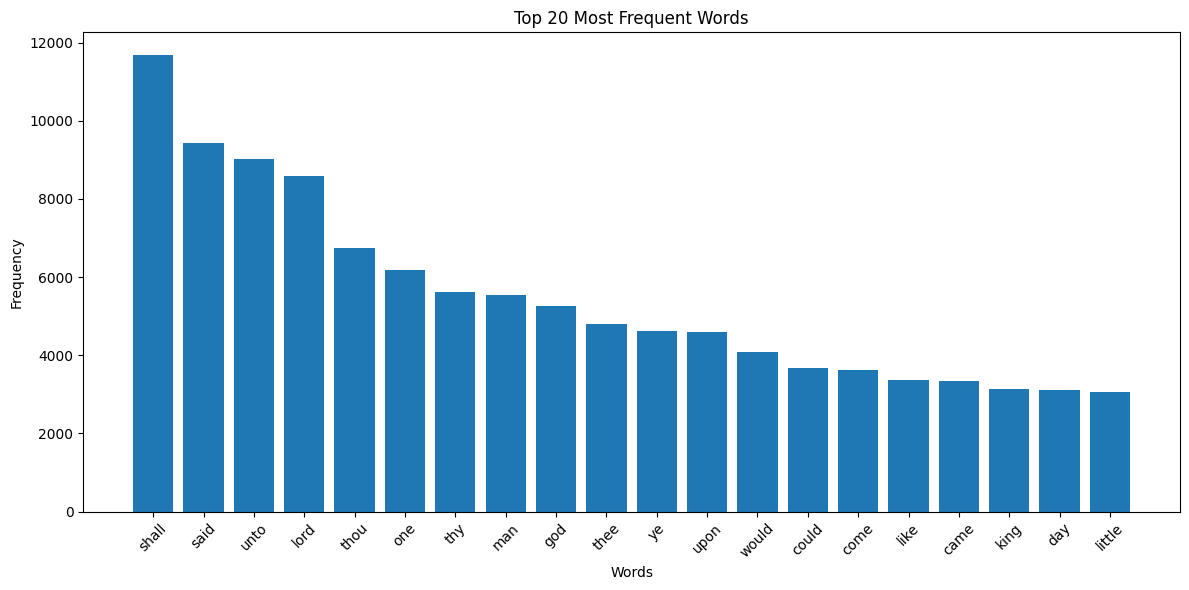

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
bigrams = list(
    zip(
        autocomplete_words[:-1],
        autocomplete_words[1:]
    )
)

print("Total bigrams:", len(bigrams))
print(bigrams[:20])

Total bigrams: 2094129
[('emma', 'by'), ('by', 'jane'), ('jane', 'austen'), ('austen', 'volume'), ('volume', 'i'), ('i', 'chapter'), ('chapter', 'i'), ('i', 'emma'), ('emma', 'woodhouse'), ('woodhouse', 'handsome'), ('handsome', 'clever'), ('clever', 'and'), ('and', 'rich'), ('rich', 'with'), ('with', 'a'), ('a', 'comfortable'), ('comfortable', 'home'), ('home', 'and'), ('and', 'happy'), ('happy', 'disposition')]


In [19]:
bigram_model = defaultdict(Counter)

for word1, word2 in bigrams:
    bigram_model[word1][word2] += 1

In [20]:
print(bigram_model["the"])

Counter({'lord': 7080, 'king': 1903, 'son': 1541, 'children': 1526, 'house': 1522, 'land': 1345, 'people': 1343, 'earth': 1164, 'same': 1133, 'other': 1015, 'world': 871, 'first': 871, 'sea': 726, 'man': 688, 'little': 661, 'whole': 657, 'day': 600, 'city': 597, 'sons': 597, 'word': 595, 'way': 574, 'great': 544, 'most': 520, 'priest': 515, 'old': 501, 'time': 495, 'hand': 486, 'men': 483, 'door': 478, 'rest': 466, 'name': 454, 'two': 447, 'midst': 438, 'very': 391, 'whale': 391, 'law': 384, 'sun': 375, 'last': 368, 'end': 362, 'morning': 356, 'place': 347, 'congregation': 333, 'ship': 332, 'ground': 330, 'young': 328, 'days': 323, 'sword': 320, 'spirit': 317, 'words': 307, 'holy': 305, 'next': 302, 'room': 301, 'poor': 295, 'altar': 289, 'god': 289, 'tabernacle': 289, 'field': 287, 'best': 285, 'priests': 280, 'wilderness': 278, 'voice': 275, 'wicked': 274, 'night': 272, 'head': 271, 'father': 269, 'water': 264, 'chief': 262, 'philistines': 257, 'right': 255, 'second': 254, 'sight': 2

In [21]:
def autocomplete(prefix, top_n=3):
    
    prefix = prefix.lower().strip()
    
    if prefix == "":
        return []
    
    last_word = prefix.split()[-1]
    
    predictions = bigram_model.get(last_word, Counter())
    
    return predictions.most_common(top_n)

In [22]:
print(autocomplete("the"))

[('lord', 7080), ('king', 1903), ('son', 1541)]


In [23]:
test_prefixes = [
    "the",
    "of",
    "to",
    "in",
    "and",
    "a",
    "for",
    "with",
    "from",
    "this"
]

for prefix in test_prefixes:
    
    predictions = autocomplete(prefix, 3)
    
    print(f"{prefix} -> {predictions}")

the -> [('lord', 7080), ('king', 1903), ('son', 1541)]
of -> [('the', 19134), ('his', 2688), ('a', 1972)]
to -> [('the', 5416), ('be', 3465), ('his', 1031)]
in -> [('the', 10241), ('a', 2059), ('his', 1754)]
and -> [('the', 8905), ('he', 3597), ('i', 2453)]
a -> [('man', 1129), ('little', 943), ('great', 848)]
for -> [('the', 3051), ('a', 1270), ('i', 694)]
with -> [('the', 2404), ('a', 1752), ('his', 789)]
from -> [('the', 2683), ('his', 414), ('him', 224)]
this -> [('is', 698), ('day', 412), ('was', 261)]


In [24]:
autocomplete_results = []

for prefix in test_prefixes:
    
    predictions = autocomplete(prefix, 3)
    
    prediction_words = [
        word for word, frequency in predictions
    ]
    
    while len(prediction_words) < 3:
        prediction_words.append("N/A")
    
    autocomplete_results.append([
        prefix,
        prediction_words[0],
        prediction_words[1],
        prediction_words[2]
    ])

autocomplete_df = pd.DataFrame(
    autocomplete_results,
    columns=[
        "Input Prefix",
        "Prediction 1",
        "Prediction 2",
        "Prediction 3"
    ]
)

autocomplete_df

,Input Prefix,Prediction 1,Prediction 2,Prediction 3
0,the,lord,king,son
1,of,the,his,a
2,to,the,be,his
3,in,the,a,his
4,and,the,he,i
5,a,man,little,great
6,for,the,a,i
7,with,the,a,his
8,from,the,his,him
9,this,is,day,was


In [25]:
autocomplete_test = {}

for prefix in test_prefixes:
    
    predictions = autocomplete(prefix, 3)
    
    if predictions:
        autocomplete_test[prefix] = predictions[0][0]

autocomplete_test

{'the': 'lord',
 'of': 'the',
 'to': 'the',
 'in': 'the',
 'and': 'the',
 'a': 'man',
 'for': 'the',
 'with': 'the',
 'from': 'the',
 'this': 'is'}

In [26]:
correct_predictions = 0

for prefix, actual_word in autocomplete_test.items():
    
    predictions = [
        word for word, frequency
        in autocomplete(prefix, 3)
    ]
    
    if actual_word in predictions:
        correct_predictions += 1
        
    print(
        "Prefix:", prefix,
        "| Actual:", actual_word,
        "| Predicted:", predictions
    )

Prefix: the | Actual: lord | Predicted: ['lord', 'king', 'son']
Prefix: of | Actual: the | Predicted: ['the', 'his', 'a']
Prefix: to | Actual: the | Predicted: ['the', 'be', 'his']
Prefix: in | Actual: the | Predicted: ['the', 'a', 'his']
Prefix: and | Actual: the | Predicted: ['the', 'he', 'i']
Prefix: a | Actual: man | Predicted: ['man', 'little', 'great']
Prefix: for | Actual: the | Predicted: ['the', 'a', 'i']
Prefix: with | Actual: the | Predicted: ['the', 'a', 'his']
Prefix: from | Actual: the | Predicted: ['the', 'his', 'him']
Prefix: this | Actual: is | Predicted: ['is', 'day', 'was']


In [27]:
total_tests = len(autocomplete_test)

autocomplete_recall = (
    correct_predictions / total_tests
)

print(
    "Autocomplete Recall:",
    round(autocomplete_recall, 3)
)

Autocomplete Recall: 1.0


In [28]:
spell = SpellChecker()

In [29]:
print(spell.correction("recieve"))

receive


In [30]:
misspelled_words = [
    "recieve",
    "teh",
    "acheive",
    "definately",
    "seperate",
    "occured",
    "untill",
    "becuase",
    "enviroment",
    "goverment",
    "adress",
    "begining",
    "calender",
    "comming",
    "freind",
    "wierd",
    "sucess",
    "tommorow",
    "responsibile",
    "knowlege"
]

In [31]:
correct_words = [
    "receive",
    "the",
    "achieve",
    "definitely",
    "separate",
    "occurred",
    "until",
    "because",
    "environment",
    "government",
    "address",
    "beginning",
    "calendar",
    "coming",
    "friend",
    "weird",
    "success",
    "tomorrow",
    "responsible",
    "knowledge"
]

In [32]:
print("Misspelled words:", len(misspelled_words))
print("Correct words:", len(correct_words))

Misspelled words: 20
Correct words: 20


In [33]:
spell_results = []

for misspelled, actual in zip(
    misspelled_words,
    correct_words
):
    
    predicted = spell.correction(misspelled)
    
    spell_results.append([
        misspelled,
        actual,
        predicted
    ])

In [34]:
spell_results = []

for misspelled, actual in zip(
    misspelled_words,
    correct_words
):
    
    predicted = spell.correction(misspelled)
    
    spell_results.append([
        misspelled,
        actual,
        predicted
    ])

In [36]:
spell_df = pd.DataFrame(
    spell_results,
    columns=[
        "Misspelled",
        "Actual",
        "Predicted"
    ]
)

spell_df

,Misspelled,Actual,Predicted
0,recieve,receive,receive
1,teh,the,the
2,acheive,achieve,achieve
3,definately,definitely,definitely
4,seperate,separate,separate
5,occured,occurred,occurred
6,untill,until,until
7,becuase,because,because
8,enviroment,environment,environment
9,goverment,government,government


In [37]:
spell_df["Correct"] = (
    spell_df["Actual"] ==
    spell_df["Predicted"]
)

spell_accuracy = spell_df["Correct"].mean()

print(
    "PySpellChecker Accuracy:",
    round(spell_accuracy * 100, 2),
    "%"
)

PySpellChecker Accuracy: 90.0 %


In [38]:
tp_spell = spell_df["Correct"].sum()

total_words = len(spell_df)

fp_spell = total_words - tp_spell
fn_spell = total_words - tp_spell

precision_spell = (
    tp_spell / (tp_spell + fp_spell)
)

recall_spell = (
    tp_spell / (tp_spell + fn_spell)
)

print(
    "Precision:",
    round(precision_spell, 3)
)

print(
    "Recall:",
    round(recall_spell, 3)
)

Precision: 0.9
Recall: 0.9


In [39]:
def levenshtein_distance(word1, word2):
    
    m = len(word1)
    n = len(word2)
    
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    
    for i in range(m + 1):
        dp[i][0] = i
    
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        
        for j in range(1, n + 1):
            
            if word1[i - 1] == word2[j - 1]:
                cost = 0
            else:
                cost = 1
            
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )
    
    return dp[m][n]

In [40]:
print(
    levenshtein_distance(
        "recieve",
        "receive"
    )
)

2


In [42]:
word_counts = Counter(autocomplete_words)

vocabulary = [
    word
    for word, count
    in word_counts.most_common(10000)
]

print("Vocabulary size:", len(vocabulary))

Vocabulary size: 10000


In [43]:
def custom_autocorrect(word):
    
    best_word = None
    best_distance = float("inf")
    
    for candidate in vocabulary:
        
        distance = levenshtein_distance(
            word,
            candidate
        )
        
        if distance < best_distance:
            best_distance = distance
            best_word = candidate
    
    return best_word

In [44]:
print(
    custom_autocorrect("recieve")
)

relieve


In [45]:
comparison_results = []

for misspelled, actual in zip(
    misspelled_words,
    correct_words
):
    
    pyspell_prediction = spell.correction(
        misspelled
    )
    
    levenshtein_prediction = custom_autocorrect(
        misspelled
    )
    
    comparison_results.append([
        misspelled,
        actual,
        pyspell_prediction,
        levenshtein_prediction
    ])

In [46]:
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Misspelled",
        "Actual",
        "PySpellChecker",
        "Levenshtein"
    ]
)

comparison_df

,Misspelled,Actual,PySpellChecker,Levenshtein
0,recieve,receive,receive,relieve
1,teh,the,the,ten
2,acheive,achieve,achieve,active
3,definately,definitely,definitely,infinitely
4,seperate,separate,separate,separate
5,occured,occurred,occurred,occurred
6,untill,until,until,until
7,becuase,because,because,because
8,enviroment,environment,environment,engagement
9,goverment,government,government,government


In [47]:
pyspell_correct = (
    comparison_df["Actual"] ==
    comparison_df["PySpellChecker"]
)

levenshtein_correct = (
    comparison_df["Actual"] ==
    comparison_df["Levenshtein"]
)

pyspell_accuracy = pyspell_correct.mean()

levenshtein_accuracy = levenshtein_correct.mean()

print(
    "PySpellChecker Accuracy:",
    round(pyspell_accuracy * 100, 2),
    "%"
)

print(
    "Levenshtein Accuracy:",
    round(levenshtein_accuracy * 100, 2),
    "%"
)

PySpellChecker Accuracy: 90.0 %
Levenshtein Accuracy: 50.0 %


In [48]:
tp_lev = levenshtein_correct.sum()

total = len(comparison_df)

fp_lev = total - tp_lev
fn_lev = total - tp_lev

precision_lev = (
    tp_lev / (tp_lev + fp_lev)
)

recall_lev = (
    tp_lev / (tp_lev + fn_lev)
)

print(
    "Levenshtein Precision:",
    round(precision_lev, 3)
)

print(
    "Levenshtein Recall:",
    round(recall_lev, 3)
)

Levenshtein Precision: 0.5
Levenshtein Recall: 0.5


In [49]:
actual = np.ones(len(comparison_df))

predicted = (
    comparison_df["Actual"] ==
    comparison_df["PySpellChecker"]
).astype(int)

cm = confusion_matrix(
    actual,
    predicted,
    labels=[0, 1]
)

print(cm)

[[ 0  0]
 [ 2 18]]


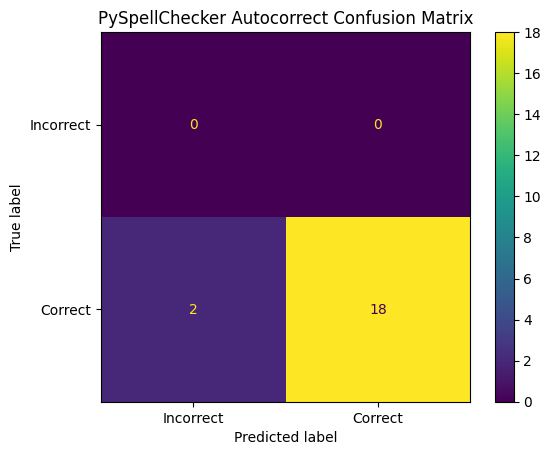

In [50]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Incorrect",
        "Correct"
    ]
)

disp.plot()

plt.title(
    "PySpellChecker Autocorrect Confusion Matrix"
)

plt.show()

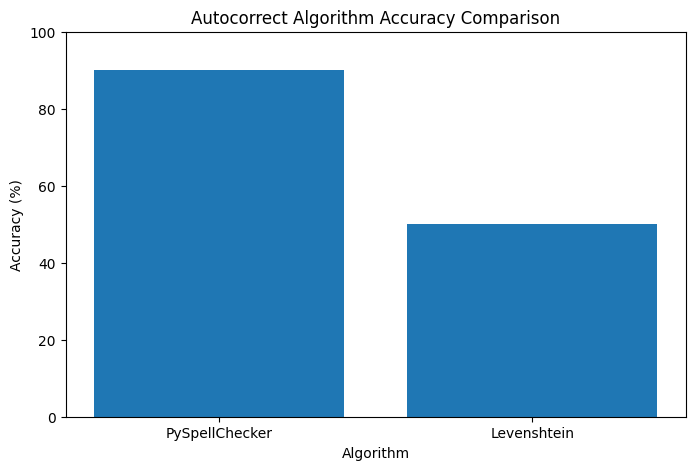

In [51]:
algorithms = [
    "PySpellChecker",
    "Levenshtein"
]

accuracies = [
    pyspell_accuracy * 100,
    levenshtein_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    algorithms,
    accuracies
)

plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.title(
    "Autocorrect Algorithm Accuracy Comparison"
)

plt.ylim(0, 100)

plt.show()

In [52]:
comparison_metrics = pd.DataFrame({
    "Algorithm": [
        "PySpellChecker",
        "Levenshtein"
    ],
    
    "Precision": [
        precision_spell,
        precision_lev
    ],
    
    "Recall": [
        recall_spell,
        recall_lev
    ],
    
    "Accuracy": [
        pyspell_accuracy,
        levenshtein_accuracy
    ]
})

comparison_metrics

,Algorithm,Precision,Recall,Accuracy
0,PySpellChecker,0.9,0.9,0.9
1,Levenshtein,0.5,0.5,0.5


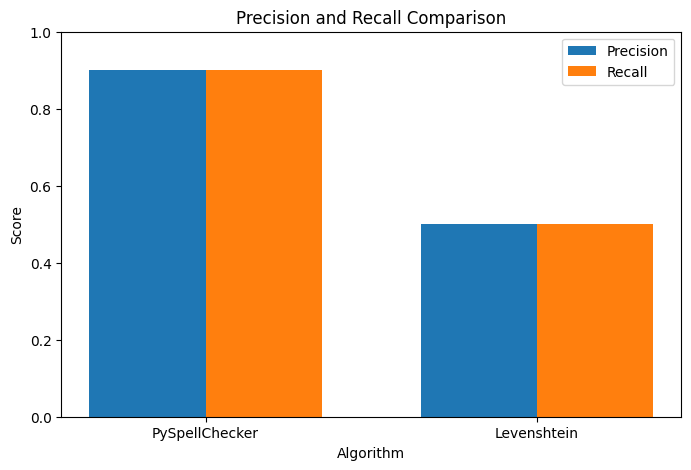

In [54]:
x = np.arange(len(comparison_metrics["Algorithm"]))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    comparison_metrics["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    comparison_metrics["Recall"],
    width,
    label="Recall"
)

plt.xticks(
    x,
    comparison_metrics["Algorithm"]
)

plt.ylabel("Score")
plt.xlabel("Algorithm")

plt.title(
    "Precision and Recall Comparison"
)

plt.ylim(0, 1)

plt.legend()

plt.show()

In [56]:
test_prefixes = [
    "the",
    "of",
    "to",
    "in",
    "and",
    "a",
    "for",
    "with",
    "from",
    "this"
]

autocomplete_test = {}

for prefix in test_prefixes:
    predictions = autocomplete(prefix, 3)

    if predictions:
        autocomplete_test[prefix] = predictions[0][0]

print(autocomplete_test)

{'the': 'lord', 'of': 'the', 'to': 'the', 'in': 'the', 'and': 'the', 'a': 'man', 'for': 'the', 'with': 'the', 'from': 'the', 'this': 'is'}


In [58]:
correct_predictions = 0

for prefix, actual_word in autocomplete_test.items():

    predictions = [
        word for word, frequency in autocomplete(prefix, 3)
    ]

    if actual_word in predictions:
        correct_predictions += 1

    print(
        "Prefix:", prefix,
        "| Actual:", actual_word,
        "| Predicted:", predictions
    )

total_tests = len(autocomplete_test)

autocomplete_recall = (
    correct_predictions / total_tests
)

total_predictions = total_tests * 3

autocomplete_precision = (
    correct_predictions / total_predictions
)

print("\nAutocomplete Precision:",
      round(autocomplete_precision, 3))

print("Autocomplete Recall:",
      round(autocomplete_recall, 3))

Prefix: the | Actual: lord | Predicted: ['lord', 'king', 'son']
Prefix: of | Actual: the | Predicted: ['the', 'his', 'a']
Prefix: to | Actual: the | Predicted: ['the', 'be', 'his']
Prefix: in | Actual: the | Predicted: ['the', 'a', 'his']
Prefix: and | Actual: the | Predicted: ['the', 'he', 'i']
Prefix: a | Actual: man | Predicted: ['man', 'little', 'great']
Prefix: for | Actual: the | Predicted: ['the', 'a', 'i']
Prefix: with | Actual: the | Predicted: ['the', 'a', 'his']
Prefix: from | Actual: the | Predicted: ['the', 'his', 'him']
Prefix: this | Actual: is | Predicted: ['is', 'day', 'was']

Autocomplete Precision: 0.333
Autocomplete Recall: 1.0


In [59]:
final_results = pd.DataFrame({
    "System": [
        "Autocomplete",
        "PySpellChecker",
        "Levenshtein"
    ],

    "Precision": [
        autocomplete_precision,
        precision_spell,
        precision_lev
    ],

    "Recall": [
        autocomplete_recall,
        recall_spell,
        recall_lev
    ],

    "Accuracy": [
        np.nan,
        pyspell_accuracy,
        levenshtein_accuracy
    ]
})

final_results

,System,Precision,Recall,Accuracy
0,Autocomplete,0.333333,1.0,NaN
1,PySpellChecker,0.900000,0.9,0.9
2,Levenshtein,0.500000,0.5,0.5


In [60]:
print("Autocomplete Test Results")
print("=" * 50)

for prefix in test_prefixes:
    
    predictions = autocomplete(prefix, 3)
    
    print(
        f"\nInput: {prefix}"
    )
    
    for rank, (word, frequency) in enumerate(
        predictions,
        start=1
    ):
        print(
            f"{rank}. {word} "
            f"(frequency: {frequency})"
        )

Autocomplete Test Results

Input: the
1. lord (frequency: 7080)
2. king (frequency: 1903)
3. son (frequency: 1541)

Input: of
1. the (frequency: 19134)
2. his (frequency: 2688)
3. a (frequency: 1972)

Input: to
1. the (frequency: 5416)
2. be (frequency: 3465)
3. his (frequency: 1031)

Input: in
1. the (frequency: 10241)
2. a (frequency: 2059)
3. his (frequency: 1754)

Input: and
1. the (frequency: 8905)
2. he (frequency: 3597)
3. i (frequency: 2453)

Input: a
1. man (frequency: 1129)
2. little (frequency: 943)
3. great (frequency: 848)

Input: for
1. the (frequency: 3051)
2. a (frequency: 1270)
3. i (frequency: 694)

Input: with
1. the (frequency: 2404)
2. a (frequency: 1752)
3. his (frequency: 789)

Input: from
1. the (frequency: 2683)
2. his (frequency: 414)
3. him (frequency: 224)

Input: this
1. is (frequency: 698)
2. day (frequency: 412)
3. was (frequency: 261)


In [62]:
import time

In [63]:
start_time = time.time()

for prefix in test_prefixes:
    autocomplete(prefix, 3)

end_time = time.time()

autocomplete_time = end_time - start_time

print(
    "Autocomplete execution time:",
    round(autocomplete_time, 6),
    "seconds"
)

Autocomplete execution time: 0.010988 seconds


In [64]:
start_time = time.time()

for word in misspelled_words:
    spell.correction(word)

end_time = time.time()

pyspell_time = end_time - start_time

print(
    "PySpellChecker execution time:",
    round(pyspell_time, 6),
    "seconds"
)

PySpellChecker execution time: 0.414784 seconds


In [65]:
start_time = time.time()

for word in misspelled_words:
    custom_autocorrect(word)

end_time = time.time()

levenshtein_time = end_time - start_time

print(
    "Levenshtein execution time:",
    round(levenshtein_time, 6),
    "seconds"
)

Levenshtein execution time: 3.425642 seconds


In [66]:
time_comparison = pd.DataFrame({
    "Algorithm": [
        "Autocomplete",
        "PySpellChecker",
        "Levenshtein"
    ],
    
    "Execution Time (seconds)": [
        autocomplete_time,
        pyspell_time,
        levenshtein_time
    ]
})

time_comparison

,Algorithm,Execution Time (seconds)
0,Autocomplete,0.010988
1,PySpellChecker,0.414784
2,Levenshtein,3.425642


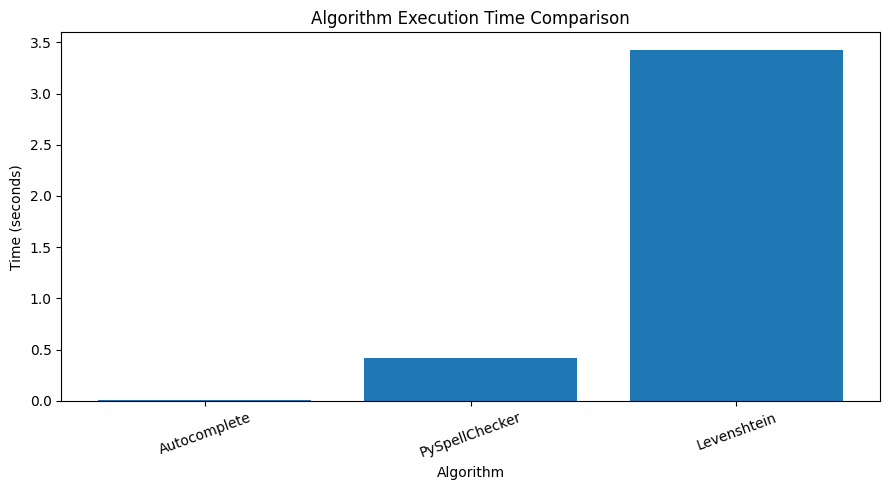

In [67]:
plt.figure(figsize=(9, 5))

plt.bar(
    time_comparison["Algorithm"],
    time_comparison["Execution Time (seconds)"]
)

plt.xlabel("Algorithm")
plt.ylabel("Time (seconds)")

plt.title(
    "Algorithm Execution Time Comparison"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [68]:
final_results = pd.DataFrame({
    "Algorithm": [
        "Frequency-based Bigram",
        "PySpellChecker",
        "Custom Levenshtein"
    ],
    
    "Precision": [
        autocomplete_precision,
        precision_spell,
        precision_lev
    ],
    
    "Recall": [
        autocomplete_recall,
        recall_spell,
        recall_lev
    ],
    
    "Accuracy": [
        np.nan,
        pyspell_accuracy,
        levenshtein_accuracy
    ],
    
    "Execution Time": [
        autocomplete_time,
        pyspell_time,
        levenshtein_time
    ]
})

final_results

,Algorithm,Precision,Recall,Accuracy,Execution Time
0,Frequency-based Bigram,0.333333,1.0,NaN,0.010988
1,PySpellChecker,0.900000,0.9,0.9,0.414784
2,Custom Levenshtein,0.500000,0.5,0.5,3.425642


Limitations
Limited context: Uses only the previous word.

No semantic understanding: Does not understand sentence meaning.

Limited vocabulary: Depends on the Gutenberg corpus.

No personalization: Does not learn the user's typing habits.

Basic spelling correction: Edit distance may give unsuitable corrections.

Slower with large vocabulary: More words require more comparisons.

Less advanced than production systems: Modern keyboards use advanced contextual language models.